In [16]:
import sys

# Prioritize the current repository source over an older installed copy.
sys.path.insert(0, "/workspaces/featuregraph/src")

import featuregraph as fg

print(fg.__file__)
print(fg.datasets.__file__)
print(hasattr(fg.datasets, "capnobase"))

/workspaces/featuregraph/src/featuregraph/__init__.py
/workspaces/featuregraph/src/featuregraph/datasets/__init__.py
True


In [17]:
df = fg.datasets.capnobase(case="0009")
labels = fg.datasets.capnobase_labels(case="0009")

In [18]:
print("Signals:", df.shape)
print("Labels:", labels.shape)
print("\nLabel types:")
print(labels["event_type"].value_counts())

Signals: (144001, 6)
Labels: (1935, 5)

Label types:
event_type
pleth_peak       816
ecg_peak         815
co2_startinsp    152
co2_startexp     152
Name: count, dtype: int64


In [19]:
df

,case_id,sample_index,time_seconds,capnogram,ppg,ecg
0,0009,0,0.000000,1.50,-0.64,-0.31
1,0009,1,0.003333,1.54,-0.64,-0.34
2,0009,2,0.006667,1.59,-0.67,-0.31
3,0009,3,0.010000,1.64,-0.69,-0.26
4,0009,4,0.013333,1.68,-0.72,-0.18
...,...,...,...,...,...,...
143996,0009,143996,479.986667,7.69,-2.21,-0.50
143997,0009,143997,479.990000,7.69,-2.27,-0.43
143998,0009,143998,479.993333,7.69,-2.32,-0.39
143999,0009,143999,479.996667,7.69,-2.32,-0.37


In [20]:
subject_id = "0009"
sampling_rate_hz = 300
smooth_window = 10
eps = 1e-12

# Construct the respiratory envelope.
df['capnogram_smooth'] = (
    df['capnogram']
    .rolling(smooth_window, min_periods=smooth_window, center=True)
    .median()
    .rolling(smooth_window, min_periods=smooth_window, center=True)
    .mean()
)

# Mutually exclusive directional states.
df['capnogram_change'] = (
    df['capnogram_smooth'].diff()
)

df['capnogram_rising'] = (
    df['capnogram_change'].gt(eps)
)

df['capnogram_falling'] = (
    df['capnogram_change'].lt(-eps)
)

df['capnogram_inactive'] = (
    df['capnogram_change'].abs().le(eps)
)

df['enter_capnogram_rising'] = df['capnogram_rising'].astype(int).diff().eq(1)
df['exit_capnogram_rising'] = df['capnogram_rising'].astype(int).diff().eq(-1)

df['sig_diff'] = df['capnogram'] - df['capnogram_smooth']


(<Figure size 1600x1100 with 5 Axes>,
 array([<Axes: ylabel='capnogram'>, <Axes: ylabel='capnogram_smooth'>,
        <Axes: ylabel='sig_diff'>, <Axes: ylabel='exit_capnogram_rising'>,
        <Axes: xlabel='Time', ylabel='ecg'>], dtype=object))

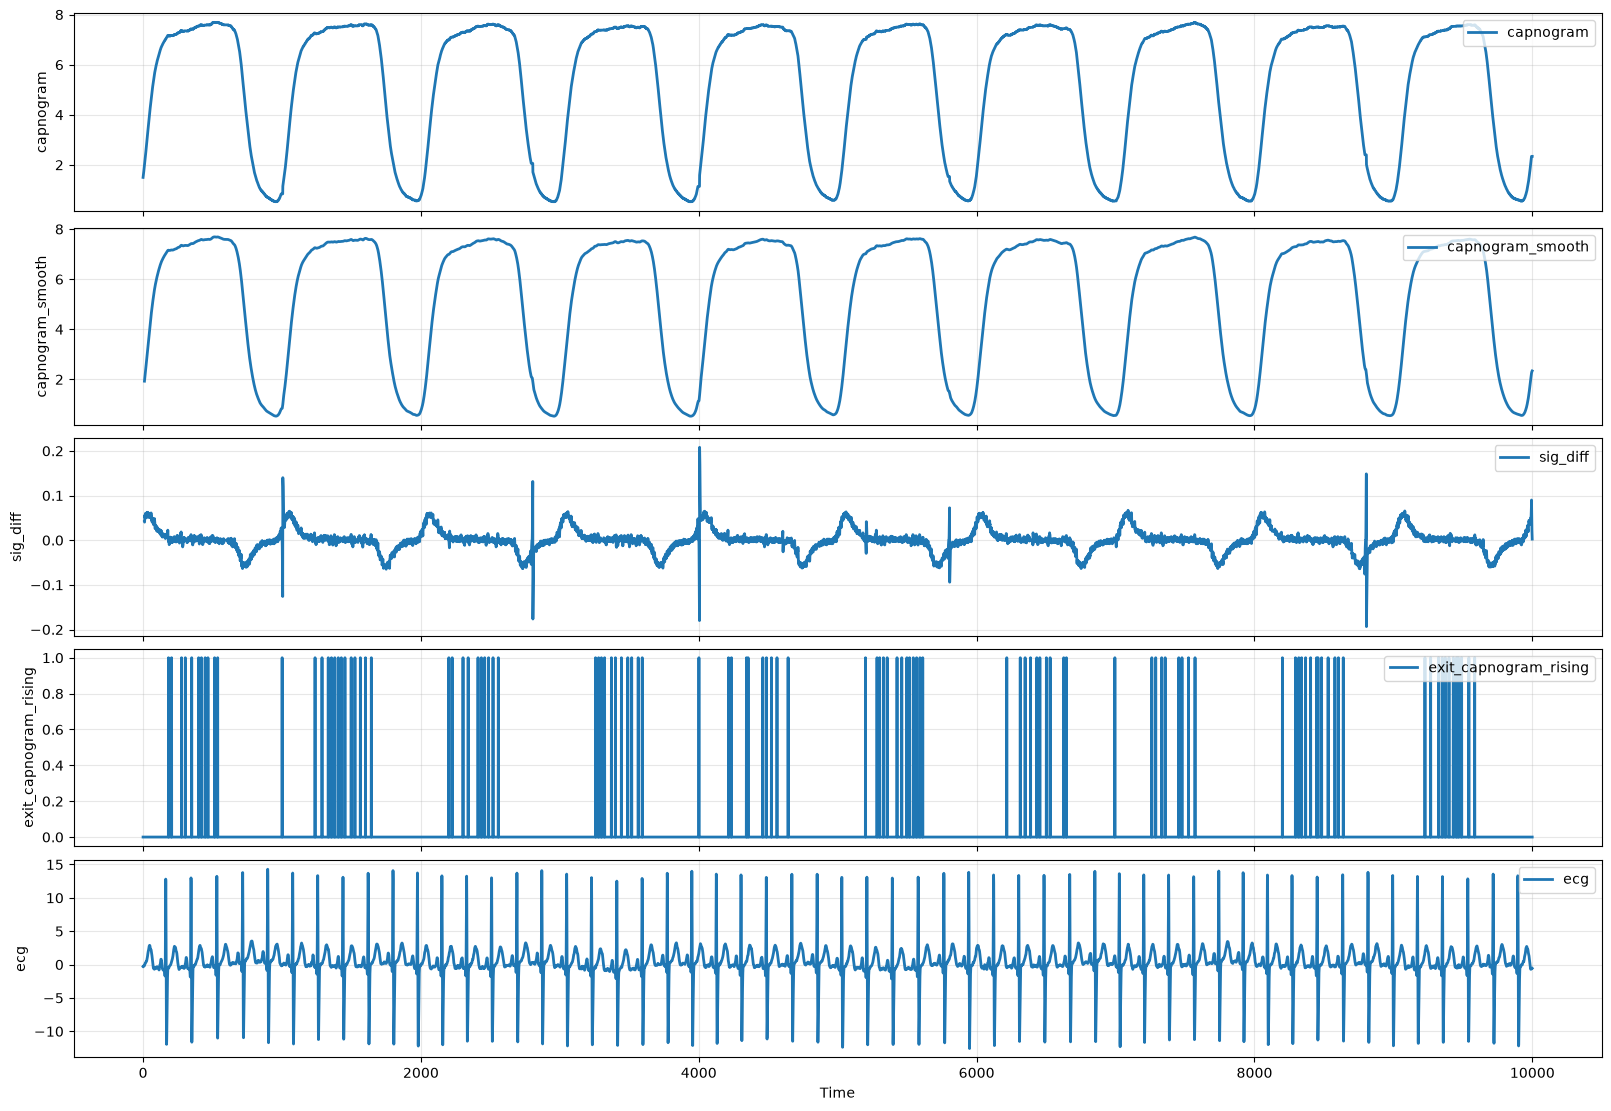

In [21]:
fg.plot(df[:10000], [['capnogram'],
                    ['capnogram_smooth'],
                    ['sig_diff'],
                    ['exit_capnogram_rising'],
                    ['ecg']
                    ]
)